# Figure 3
## GO plots
### Author: Martin Loza
### Date: 25/12/10

Let's plot the results from DAVID GO

In [1]:
# Change R language to English
Sys.setenv(LANGUAGE = "en")

# Init
suppressPackageStartupMessages({
    library(dplyr)
    library(stringr)
    library(ggplot2)
    library(patchwork)
    library(dplyr)
})

# Local variables 
seed = 777
date = "251210"

# Define colors for strand plots
red = "#E41A1C"
blue = "#377EB8"
# Define colors for gene types
green = "#4DAF4A"
purple = "#984EA3"
text_size = 18
width = 18.6
dot_size = 4
line_size = 1.5
dpi = 300

in_dir = "/Users/martin/Documents/Projects/lncRNA_TF_pairs_analysis/04_Figure_3/Results/"
out_dir = "/Users/martin/Documents/Projects/lncRNA_TF_pairs_analysis/04_Figure_3/Plots/"
# Local Functions



### Load and setup the data

In [2]:
# Load the results from the GO analysis
# We have different species, so let's create a list to store the data
data_list = list()

# Search for the available files
files <- list.files(in_dir)
# Select files that start with "DAVID_"
files <- files[str_starts(files, "DAVID_")]

# Load the data for each species
for (file in files) {
    # Remove the DAVID prefix
    species_name <- str_replace(file, "DAVID_", "")
    # Remove the underscore and everything after it to get the species names
    species_name <- str_replace(species_name, "_.*", "")
    data_list[[species_name]] <- read.csv2(file.path(in_dir, file), sep = ",", header = TRUE, 
                                            stringsAsFactors = FALSE, quote = "", 
                                            comment.char = "", fill = TRUE, row.names = NULL) %>%
        mutate(across(where(is.character), ~str_remove_all(., '"')))
    # Remove the X. prefix from column names if present
    colnames(data_list[[species_name]]) <- str_replace_all(colnames(data_list[[species_name]]), "^X\\.", "")
    # Remove the last "." from column names if present
    colnames(data_list[[species_name]]) <- str_replace_all(colnames(data_list[[species_name]]), "\\.$", "")

    # Transform selected columns to numeric
    selected_cols <- c("Count", "Benjamini", "FDR")
    data_list[[species_name]][selected_cols] <- lapply(data_list[[species_name]][selected_cols], as.numeric)
}

head(data_list[["human"]], 10)

Warning message in lapply(data_list[[species_name]][selected_cols], as.numeric):
“NAs introduced by coercion”
Warning message in lapply(data_list[[species_name]][selected_cols], as.numeric):
“NAs introduced by coercion”


,Category,Term,Genes,Count,List.Total,Pop.Hits,Pop.Total,P.Value,Benjamini,Fold.Enrichment,Bonferroni,FDR,Fisher.Exact
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>
1,GOTERM_BP_DIRECT,regulation of transcription by RNA polymerase II,10.34%,1041,8942,1711,19478,1.10e-38,1.15e-34,1.33,1.15e-34,1.14e-34,6.00e-39
2,GOTERM_BP_DIRECT,positive regulation of transcription by RNA polymerase II,7.57%,762,8942,1205,19478,8.49e-36,4.44e-32,1.38,8.89e-32,4.41e-32,4.20e-36
3,GOTERM_BP_DIRECT,negative regulation of transcription by RNA polymerase II,6.13%,617,8942,958,19478,3.48e-32,1.22e-28,1.40,3.65e-28,1.21e-28,1.64e-32
4,GOTERM_BP_DIRECT,positive regulation of DNA-templated transcription,4.41%,444,8942,714,19478,4.09e-19,1.07e-15,1.35,4.28e-15,1.06e-15,2.12e-19
5,GOTERM_BP_DIRECT,negative regulation of DNA-templated transcription,3.58%,360,8942,573,19478,2.24e-16,4.69e-13,1.37,2.32e-12,4.65e-13,5.70e-17
6,GOTERM_BP_DIRECT,regulation of DNA-templated transcription,5.58%,562,8942,980,19478,1.90e-13,3.31e-10,1.25,1.99e-9,3.29e-10,1.17e-13
7,GOTERM_BP_DIRECT,chromatin remodeling,4.06%,409,8942,686,19478,2.70e-13,4.04e-10,1.30,2.83e-9,4.01e-10,1.55e-13
8,GOTERM_BP_DIRECT,nervous system development,2.81%,283,8942,452,19478,7.78e-13,1.02e-09,1.36,8.15e-9,1.01e-09,3.93e-13
9,GOTERM_BP_DIRECT,signal transduction,7.06%,711,8942,1308,19478,2.00e-10,2.32e-07,1.18,2.09e-6,2.30e-07,1.46e-10


### Prepare the data for plotting

In [3]:
# Prepare data for plotting - select top terms by FDR
top_n_terms = 10  # Number of top terms to show

plot_data_list <- list()

for (species in names(data_list)) {
    # Select top N terms with lowest FDR
    plot_data_list[[species]] <- data_list[[species]] %>%
        arrange(FDR) %>%
        head(top_n_terms) %>%
        mutate(
            # Create a clean term name (remove GO ID if present)
            Term_clean = str_replace(Term, "~.*", ""),
            Term_clean = str_trunc(Term_clean, width = 60, side = "right"),
            # Calculate -log10(FDR) for better visualization
            neg_log_FDR = -log10(FDR)
        )
}

head(plot_data_list[["human"]], 3)

,Category,Term,Genes,Count,List.Total,Pop.Hits,Pop.Total,P.Value,Benjamini,Fold.Enrichment,Bonferroni,FDR,Fisher.Exact,Term_clean,neg_log_FDR
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>
1,GOTERM_BP_DIRECT,regulation of transcription by RNA polymerase II,10.34%,1041,8942,1711,19478,1.10e-38,1.15e-34,1.33,1.15e-34,1.14e-34,6.00e-39,regulation of transcription by RNA polymerase II,33.94310
2,GOTERM_BP_DIRECT,positive regulation of transcription by RNA polymerase II,7.57%,762,8942,1205,19478,8.49e-36,4.44e-32,1.38,8.89e-32,4.41e-32,4.20e-36,positive regulation of transcription by RNA polymerase II,31.35556
3,GOTERM_BP_DIRECT,negative regulation of transcription by RNA polymerase II,6.13%,617,8942,958,19478,3.48e-32,1.22e-28,1.40,3.65e-28,1.21e-28,1.64e-32,negative regulation of transcription by RNA polymerase II,27.91721


### GO Enrichment Plot

Lollipop plot showing GO enrichment results with -log10(FDR) and gene count.

In [5]:
# Create separate plots for each species, then combine with patchwork
options(repr.plot.width=12, repr.plot.height=8)

# Prepare data with proper ordering for each species
human_data <- plot_data_list[["human"]] %>%
    arrange(neg_log_FDR) %>%
    mutate(Term_clean = factor(Term_clean, levels = unique(Term_clean)))

mouse_data <- plot_data_list[["mouse"]] %>%
    arrange(neg_log_FDR) %>%
    mutate(Term_clean = factor(Term_clean, levels = unique(Term_clean)))

# Get the range of Count values across both species for shared scale
count_range <- range(c(human_data$Count, mouse_data$Count))


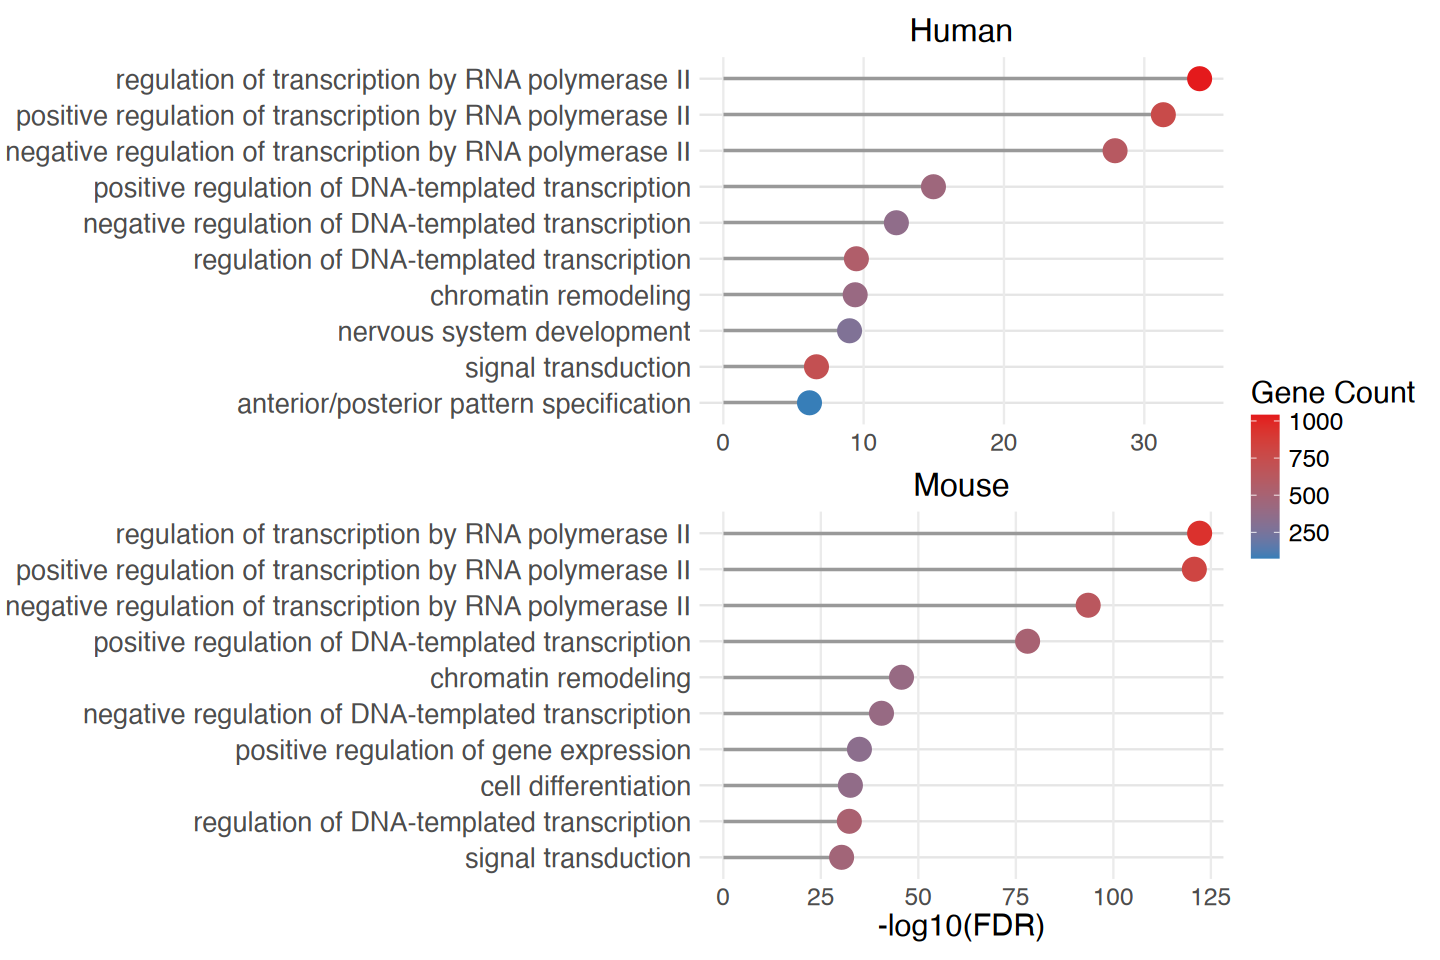

In [14]:

# Create human plot with color by count and shared scale
p_human_count <- human_data %>%
    ggplot(aes(x = neg_log_FDR, y = Term_clean)) +
    geom_segment(aes(x = 0, xend = neg_log_FDR, y = Term_clean, yend = Term_clean),
                 color = "gray60", linewidth = line_size * 0.5) +
    geom_point(aes(color = Count), size = dot_size * 1.5) +
    scale_color_gradient(low = blue, high = red, name = "Gene Count", limits = count_range) +
    theme_minimal() +
    labs(x = NULL, y = NULL, title = "Human") +
    theme(
        text = element_text(size = text_size),
        axis.text.y = element_text(size = text_size - 2),
        plot.title = element_text(size = text_size + 1, hjust = 0.5),
        legend.position = "right",
        panel.grid.major.y = element_line(color = "gray90"),
        panel.grid.minor = element_blank()
    )

# Create mouse plot with color by count and shared scale
p_mouse_count <- mouse_data %>%
    ggplot(aes(x = neg_log_FDR, y = Term_clean)) +
    geom_segment(aes(x = 0, xend = neg_log_FDR, y = Term_clean, yend = Term_clean),
                 color = "gray60", linewidth = line_size * 0.5) +
    geom_point(aes(color = Count), size = dot_size * 1.5) +
    scale_color_gradient(low = blue, high = red, name = "Gene Count", limits = count_range) +
    theme_minimal() +
    labs(x = "-log10(FDR)", y = NULL, title = "Mouse") +
    theme(
        text = element_text(size = text_size),
        axis.text.y = element_text(size = text_size - 2),
        plot.title = element_text(size = text_size + 1, hjust = 0.5),
        legend.position = "right",
        panel.grid.major.y = element_line(color = "gray90"),
        panel.grid.minor = element_blank()
    )

# Combine plots with patchwork
options(repr.plot.width=12, repr.plot.height=8)
p_lollipop <- p_human_count / p_mouse_count + 
    plot_layout(guides = "collect") +
    plot_annotation(theme = theme(plot.title = element_text(size = text_size + 2)))

p_lollipop

### Save plot

In [15]:
# Save the GO enrichment plot
ggsave(filename = file.path(out_dir, paste0("Fig_3_GO_enrichment_", date, ".pdf")),
    plot = p_lollipop, 
    width = width * 0.6, height = 8.0, units = "in", dpi = dpi)